<a href="https://colab.research.google.com/github/KrithikChidM/PrmlLab/blob/main/LAB3/code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt

def read_data(filename):
    data = []

    with open(filename, "r") as file:
        for line in file:
            line = line.strip()

            if line == "":
                continue

            values = line.split()

            if len(values) >= 2:
                x = float(values[0])
                y = float(values[1])
                data.append((x, y))

    return data


def shuffle_data(data, seed=42):
    rng = np.random.default_rng(seed)
    data = data[:]
    rng.shuffle(data)
    return data


def split_data(data):
    data = shuffle_data(data)

    n = len(data)

    train_end = int(0.60 * n)
    test_end = int(0.80 * n)

    train = data[:train_end]
    test = data[train_end:test_end]
    validation = data[test_end:]

    return train, test, validation


def normalize_data(data):
    x_values = np.array([x for x, y in data])

    minimum = np.min(x_values)
    maximum = np.max(x_values)

    result = []

    for x, y in data:
        if maximum == minimum:
            new_x = 0.0
        else:
            new_x = 2.0 * (x - minimum) / (maximum - minimum) - 1.0

        result.append((new_x, y))

    return result, minimum, maximum


def normalize_x(x, minimum, maximum):
    if maximum == minimum:
        return 0.0

    return 2.0 * (x - minimum) / (maximum - minimum) - 1.0


def create_design_matrix(data, degree):
    x_values = np.array([x for x, y in data])

    X = np.ones((len(x_values), degree + 1))

    for j in range(1, degree + 1):
        X[:, j] = x_values ** j

    return X


def transpose(A):
    return np.transpose(A)


def matrix_multiply(A, B):
    return np.matmul(A, B)


def identity_matrix(n):
    return np.eye(n)


def inverse_matrix(A):
    return np.linalg.inv(A)


def pseudo_inverse(X):
    return np.linalg.pinv(X)


def initial_weights(X, Y):
    X_pseudo = pseudo_inverse(X)

    Y = np.array(Y)

    weights = matrix_multiply(X_pseudo, Y)

    return weights


def predict(x, weights):
    result = 0.0
    power = 1.0

    for weight in weights:
        result += weight * power
        power *= x

    return result


def weight_update(data, weights, learning_rate, iterations):

    X = create_design_matrix(
        data,
        len(weights) - 1
    )

    Y = np.array([y for x, y in data])

    weights = np.array(weights, dtype=float)

    n = len(data)

    for iteration in range(iterations):

        predictions = np.matmul(X, weights)

        errors = predictions - Y

        gradients = (2.0 / n) * np.matmul(
            np.transpose(X),
            errors
        )

        weights = weights - learning_rate * gradients

    return weights


def train_polynomial(data, degree):

    X = create_design_matrix(
        data,
        degree
    )

    Y = [y for x, y in data]

    weights = initial_weights(
        X,
        Y
    )

    weights = weight_update(
        data,
        weights,
        learning_rate=0.0001,
        iterations=1000
    )

    return weights


def mse(data, weights):

    X = create_design_matrix(
        data,
        len(weights) - 1
    )

    Y = np.array([y for x, y in data])

    predictions = np.matmul(X, weights)

    errors = Y - predictions

    return np.mean(errors ** 2)


def rmse(data, weights):
    return math.sqrt(
        mse(data, weights)
    )


def r2_score(data, weights):

    Y = np.array([y for x, y in data])

    X = create_design_matrix(
        data,
        len(weights) - 1
    )

    predictions = np.matmul(X, weights)

    mean_y = np.mean(Y)

    total = np.sum(
        (Y - mean_y) ** 2
    )

    residual = np.sum(
        (Y - predictions) ** 2
    )

    if total == 0:
        return 0.0

    return 1.0 - residual / total


def polynomial_string(weights):

    expression = ""

    for i in range(len(weights)):

        if i == 0:

            expression = "%.6f" % weights[i]

        elif weights[i] >= 0:

            expression += " + %.6f*x^%d" % (
                weights[i],
                i
            )

        else:

            expression += " - %.6f*x^%d" % (
                abs(weights[i]),
                i
            )

    return expression

Dataset: /content/drive/MyDrive/Krithik SNU/HAM/noisy_7.txt
Total samples: 10000
Training samples: 6000
Testing samples: 2000
Validation samples: 2000

Polynomial Regression Experiments
----------------------------------
Degree   Train MSE       Test MSE        Validation MSE 
1        1730.146685     1780.379280     1776.504615    
2        1687.476994     1726.042589     1713.907018    
3        1450.599653     1492.895904     1468.853452    
4        1389.732335     1424.153816     1409.525477    
5        1024.775119     1069.142644     1040.984302    
6        718.695649      730.067363      713.694984     
7        718.485500      729.150697      712.316779     
8        585.256034      598.621828      568.274700     
9        364.336273      365.383878      358.600525     
10       364.276643      365.448795      358.781222     

Best Polynomial Model
---------------------
Selected Degree: 9

Weights:
w0 = -20.0225538661
w1 = 25.2517601314
w2 = 946.2563379638
w3 = 1657.627974366

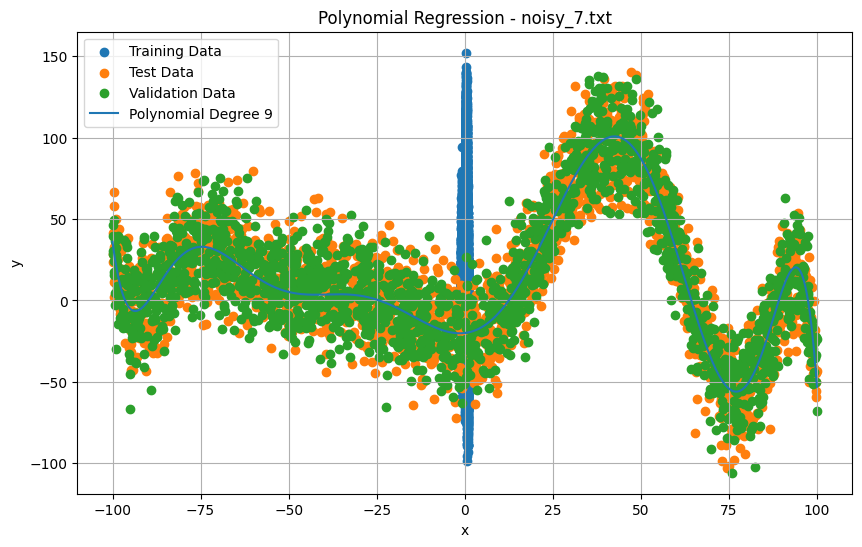

In [ ]:
import math
import matplotlib.pyplot as plt

filename = "/content/drive/MyDrive/Krithik SNU/HAM/noisy_7.txt"

data = read_data(filename)

print("Dataset:", filename)
print("Total samples:", len(data))


train, test, validation = split_data(data)

print("Training samples:", len(train))
print("Testing samples:", len(test))
print("Validation samples:", len(validation))


train, x_min, x_max = normalize_data(train)

test_normalized = []

for x, y in test:

    nx = normalize_x(
        x,
        x_min,
        x_max
    )

    test_normalized.append((nx, y))


validation_normalized = []

for x, y in validation:

    nx = normalize_x(
        x,
        x_min,
        x_max
    )

    validation_normalized.append((nx, y))


degrees = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


best_degree = None
best_test_mse = float("inf")
best_weights = None


print()
print("Polynomial Regression Experiments")
print("----------------------------------")

print(
    "%-8s %-15s %-15s %-15s"
    % (
        "Degree",
        "Train MSE",
        "Test MSE",
        "Validation MSE"
    )
)


for degree in degrees:

    weights = train_polynomial(
        train,
        degree
    )

    if weights is None:

        print(
            "%-8d Could not calculate pseudo-inverse"
            % degree
        )

        continue

    train_mse = mse(
        train,
        weights
    )

    test_mse = mse(
        test_normalized,
        weights
    )

    validation_mse = mse(
        validation_normalized,
        weights
    )

    print(
        "%-8d %-15.6f %-15.6f %-15.6f"
        % (
            degree,
            train_mse,
            test_mse,
            validation_mse
        )
    )

    if test_mse < best_test_mse:

        best_test_mse = test_mse

        best_degree = degree

        best_weights = weights


print()
print("Best Polynomial Model")
print("---------------------")

print("Selected Degree:", best_degree)

print()
print("Weights:")

for i in range(len(best_weights)):

    print(
        "w%d = %.10f"
        % (
            i,
            best_weights[i]
        )
    )


print()
print("Polynomial:")
print(polynomial_string(best_weights))


final_mse = mse(
    validation_normalized,
    best_weights
)

final_rmse = rmse(
    validation_normalized,
    best_weights
)

final_r2 = r2_score(
    validation_normalized,
    best_weights
)


print()
print("Final Validation Results")
print("------------------------")

print("Validation MSE  :", final_mse)
print("Validation RMSE :", final_rmse)
print("Validation R2   :", final_r2)


x_plot = []
y_plot = []

points = 500

for i in range(points + 1):

    x = x_min + (
        (x_max - x_min)
        * i
        / points
    )

    nx = normalize_x(
        x,
        x_min,
        x_max
    )

    y = predict(
        nx,
        best_weights
    )

    x_plot.append(x)
    y_plot.append(y)


plt.figure(figsize=(10, 6))

plt.scatter(
    [x for x, y in train],
    [y for x, y in train],
    label="Training Data"
)

plt.scatter(
    [x for x, y in test],
    [y for x, y in test],
    label="Test Data"
)

plt.scatter(
    [x for x, y in validation],
    [y for x, y in validation],
    label="Validation Data"
)

plt.plot(
    x_plot,
    y_plot,
    label="Polynomial Degree " + str(best_degree)
)

plt.xlabel("x")
plt.ylabel("y")

plt.title(
    "Polynomial Regression - noisy_7.txt"
)

plt.legend()
plt.grid(True)

plt.show()